# Task 5: Exploratory Data Analysis on Titanic Dataset

## Objective

The objective of this task is to perform Exploratory Data Analysis (EDA) on the Titanic dataset to identify patterns, trends, relationships, distributions, and anomalies using statistical and visual techniques.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Dataset

Titanic passenger dataset containing information about passengers, including survival status, passenger class, sex, age, number of siblings/spouses, parents/children, fare, cabin, and port of embarkation.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# Display plots inside notebook
%matplotlib inline

# 1. Loading the Dataset

In [12]:
df = pd.read_csv("train.csv")

In [13]:
#first rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
#last rows
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


# 2. Dataset Overview

In this section, we examine the structure, dimensions, columns, data types, and basic information about the dataset.

In [7]:
#Shape
df.shape

(891, 12)

In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 12


In [14]:
#Columns
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [15]:
#information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# 3. Statistical Summary

In [16]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [17]:
df.describe(include="object")


C:\Users\lijeesha\AppData\Local\Temp\ipykernel_14180\3764884355.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


### Observation

The descriptive statistics provide information about the central tendency, spread, minimum, maximum, and quartiles of the numerical variables.

# 4. Data Quality Analysis

## 4.1 Missing Values

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing

,Missing Values,Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


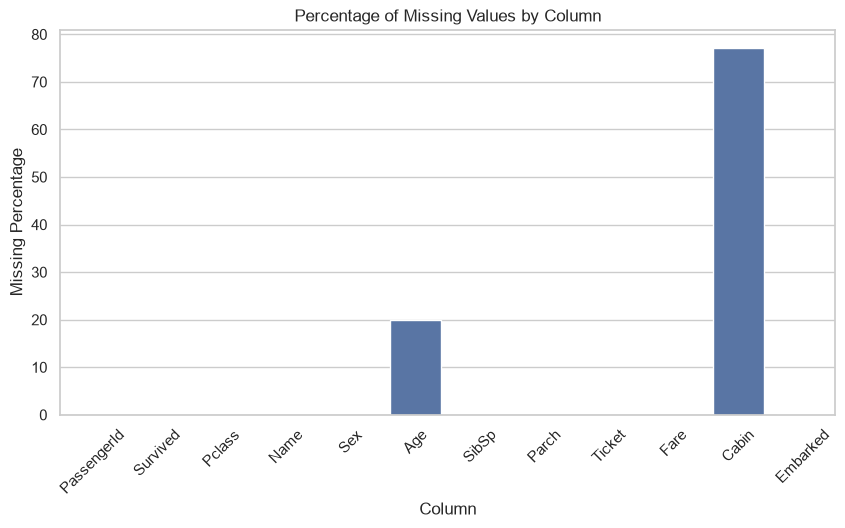

In [13]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing.index,
    y=missing["Percentage"]
)

plt.xticks(rotation=45)
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Missing Percentage")
plt.xlabel("Column")
plt.show()

### Observation

The Cabin column contains a large proportion of missing values. Age also contains missing observations, while Embarked has only a small number of missing values.

## 4.2 Duplicate Records

In [14]:
df.duplicated().sum()

np.int64(0)

### Observation

The duplicate check helps determine whether identical records are present in the dataset.

# 5. Univariate Analysis

Univariate analysis examines individual variables to understand their distributions and characteristics.

## 5.1 Survival Distribution

In [18]:
df["Survived"].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

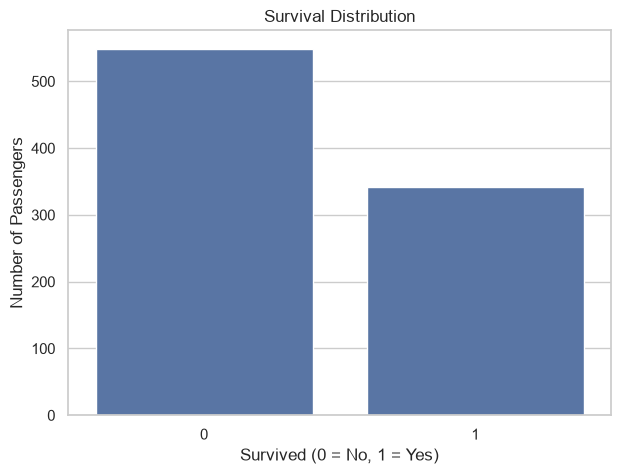

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

### Observation

The number of passengers who did not survive is higher than the number who survived.

## 5.2 Age Distribution

In [20]:
df["Age"].describe()


count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

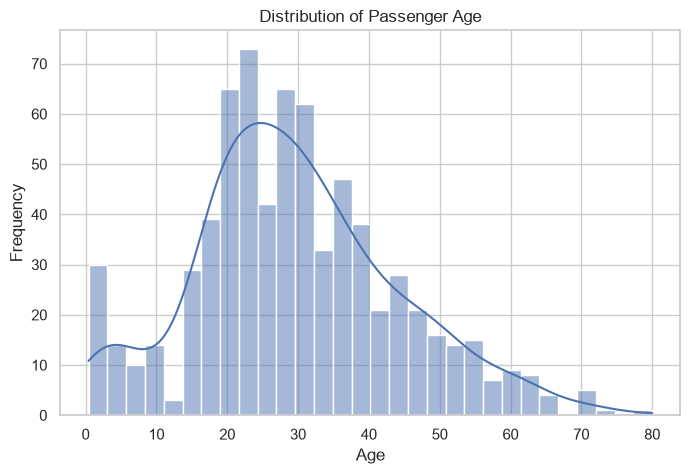

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

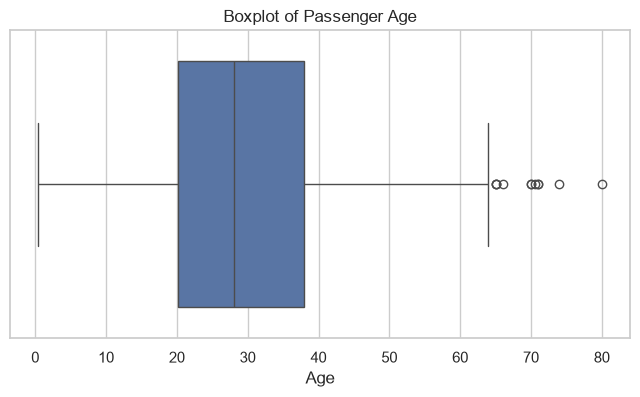

In [23]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Age"])

plt.title("Boxplot of Passenger Age")
plt.xlabel("Age")
plt.show()

## 5.3 Fare Distribution

In [24]:
df["Fare"].describe()


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

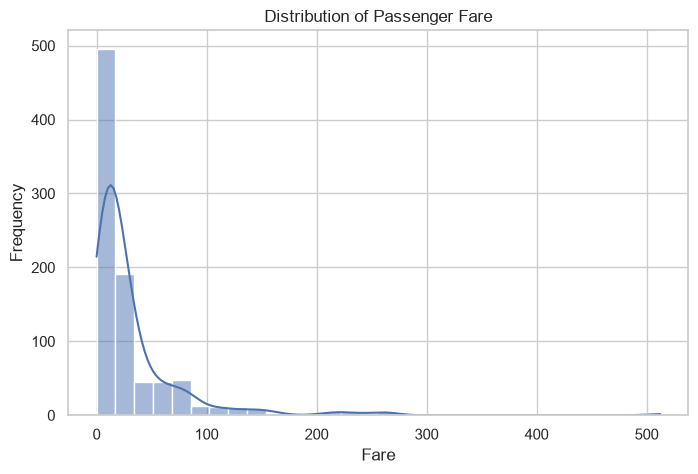

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Fare", bins=30, kde=True)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

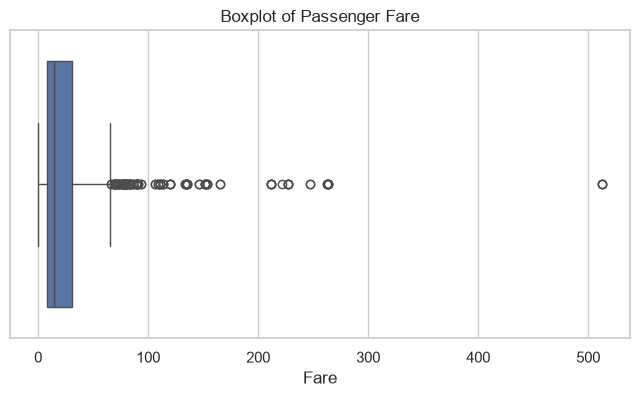

In [26]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Fare"])

plt.title("Boxplot of Passenger Fare")
plt.xlabel("Fare")
plt.show()

### Observation

The Fare variable is right-skewed. Most passengers paid relatively low fares, while a smaller number of passengers paid much higher fares, resulting in potential outliers.

## 5.4 Passenger Distribution by Sex

In [28]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

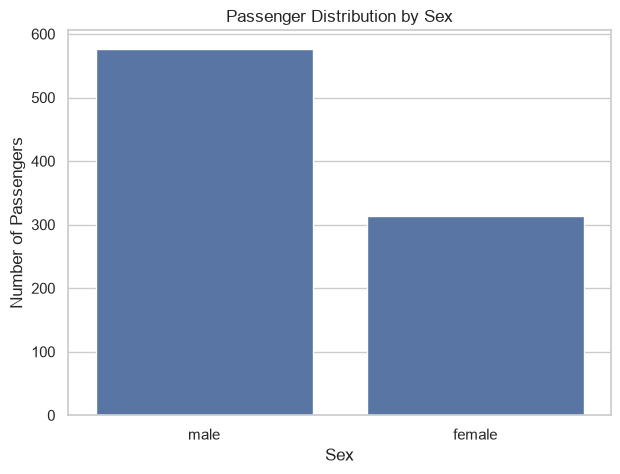

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Sex")

plt.title("Passenger Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.show()

## 5.5 Passenger Class Distribution

In [30]:
df["Pclass"].value_counts().sort_index()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

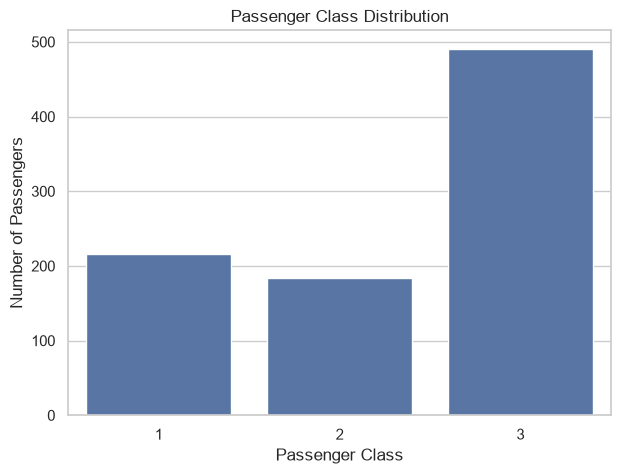

In [31]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Pclass")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

## 5.6 Embarkation Port Distribution

In [32]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

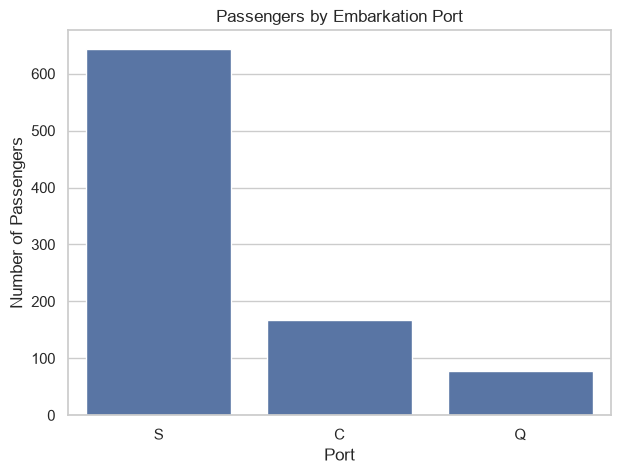

In [33]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Embarked")

plt.title("Passengers by Embarkation Port")
plt.xlabel("Port")
plt.ylabel("Number of Passengers")
plt.show()

# 6. Bivariate Analysis

Bivariate analysis examines the relationship between two variables.

## 6.1 Survival by Sex

In [34]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [35]:
df["Survived"].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

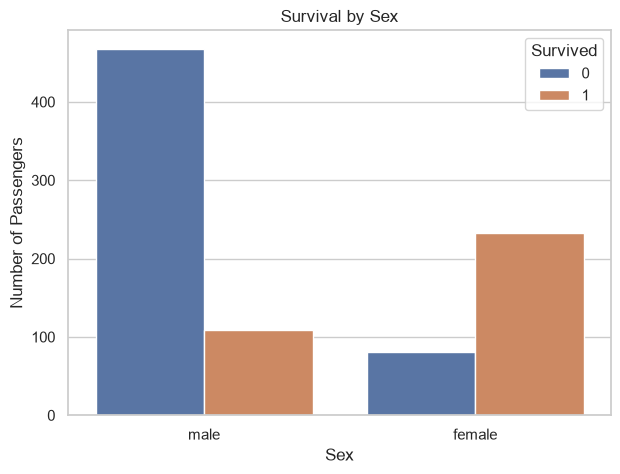

In [36]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.show()

### Observation

Female passengers had a substantially higher survival proportion than male passengers.

## 6.2 Survival by Passenger Class

In [37]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


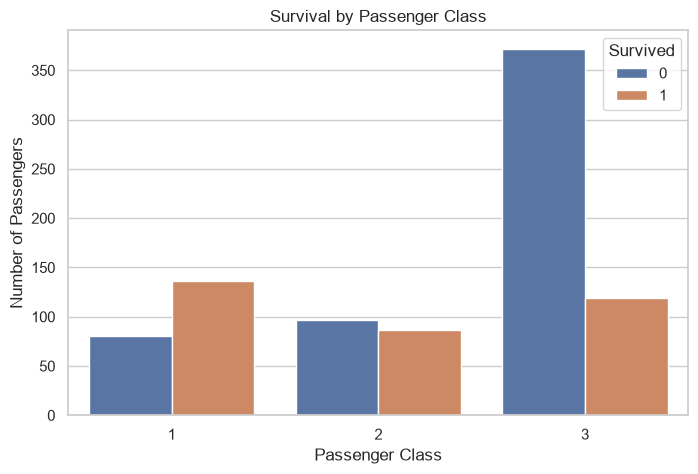

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

### Observation

First-class passengers had a higher survival proportion, while third-class passengers had the lowest survival proportion.

## 6.3 Age and Survival

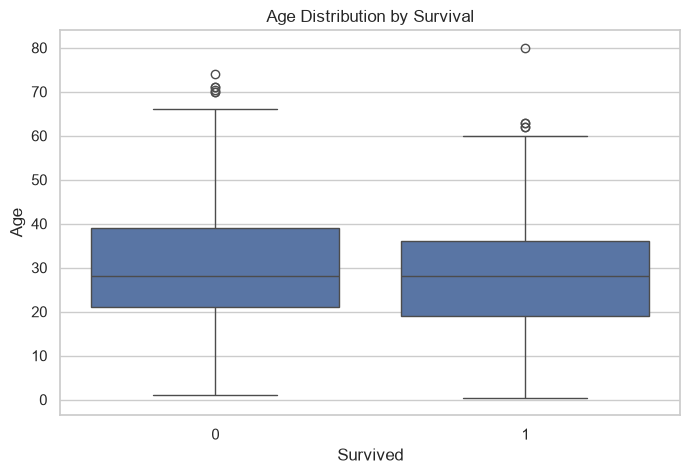

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()

## 6.4 Fare and Survival

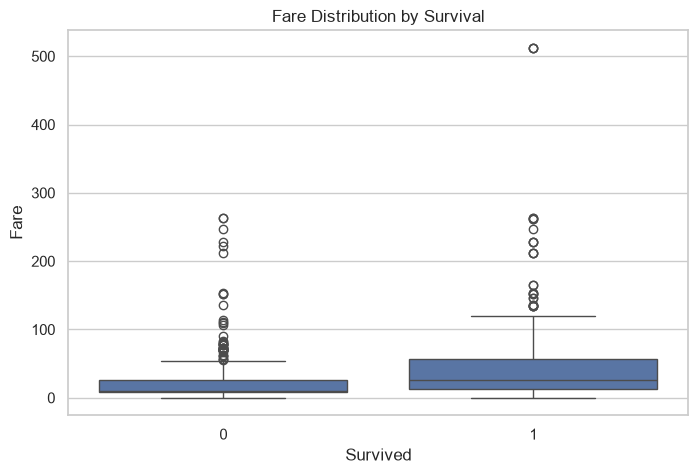

In [40]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare"
)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

# 7. Feature Engineering

A new FamilySize variable is created by combining SibSp and Parch with the passenger themselves.

In [41]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [42]:
df["FamilySize"].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

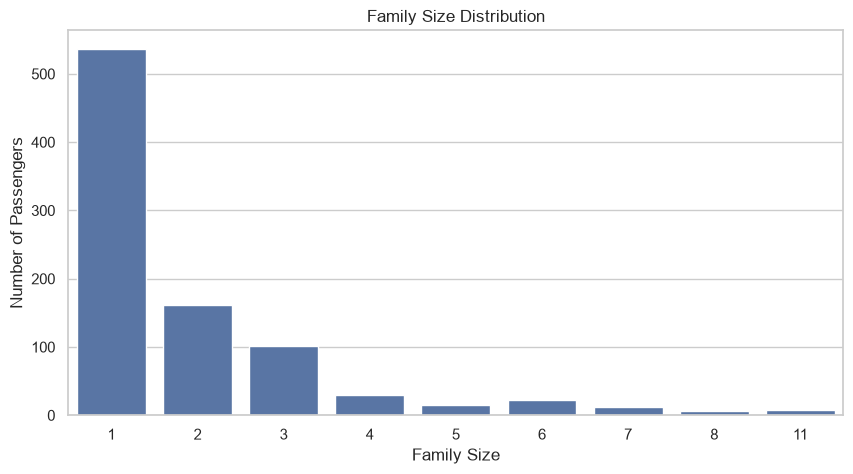

In [43]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="FamilySize"
)

plt.title("Family Size Distribution")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")
plt.show()

# 8. Multivariate Analysis

Multivariate analysis examines relationships involving three or more variables.

## 8.1 Survival by Sex and Passenger Class

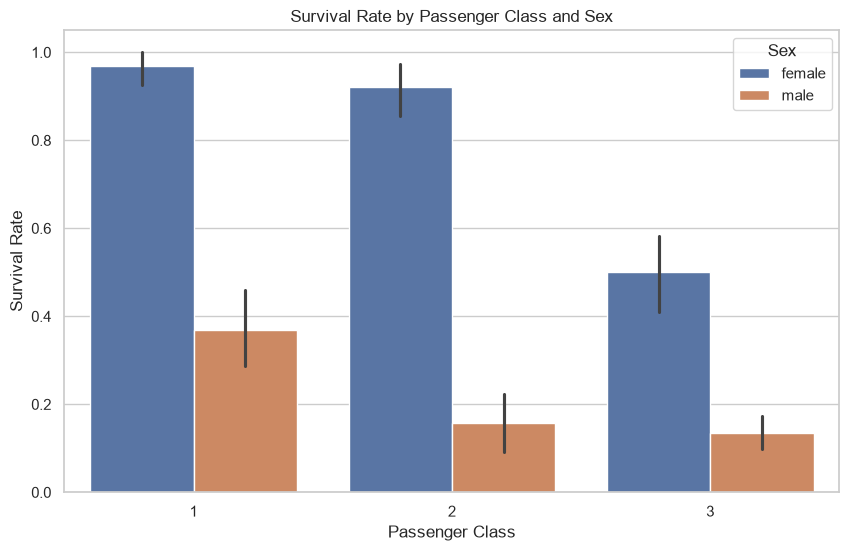

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

# 9. Correlation Analysis

In [45]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658,-0.040143
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.065997
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,-0.301914
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,0.890712
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,0.783111
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,0.217138
FamilySize,-0.040143,0.016639,0.065997,-0.301914,0.890712,0.783111,0.217138,1.000000


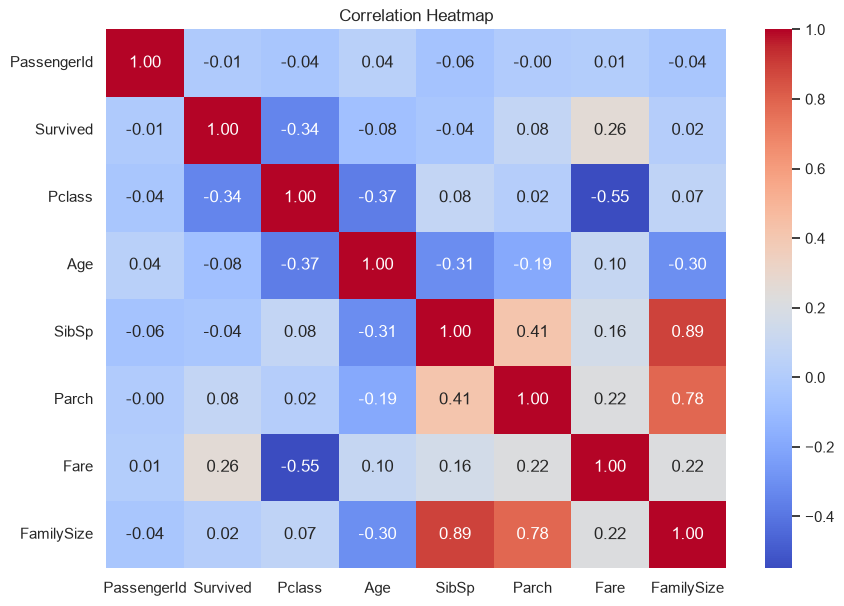

In [46]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap shows the strength and direction of linear relationships among the numerical variables. It helps identify variables that have relatively stronger associations with each other.

# 10. Pairplot Analysis

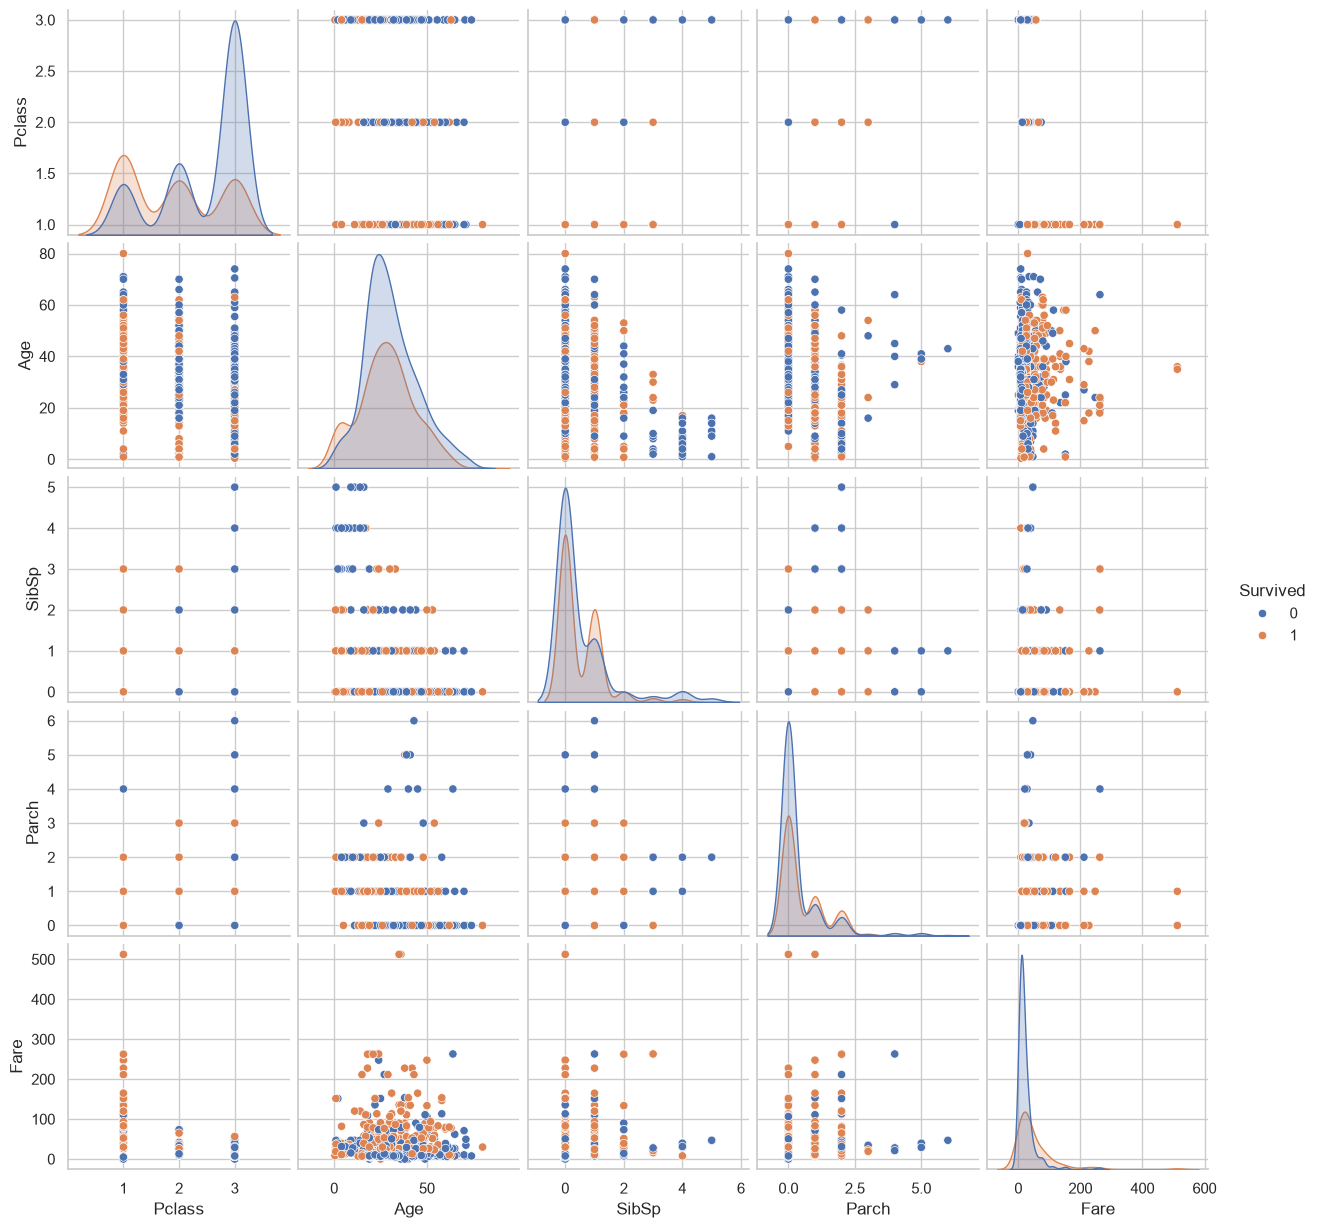

In [48]:
pairplot_data = df[
    ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
].dropna()

sns.pairplot(
    pairplot_data,
    hue="Survived"
)

plt.show()

### Observation

The pairplot provides a multivariate view of the numerical variables and allows relationships, distributions, clusters, and potential outliers to be examined simultaneously.

# 11. Scatterplot Analysis

## Age vs Fare

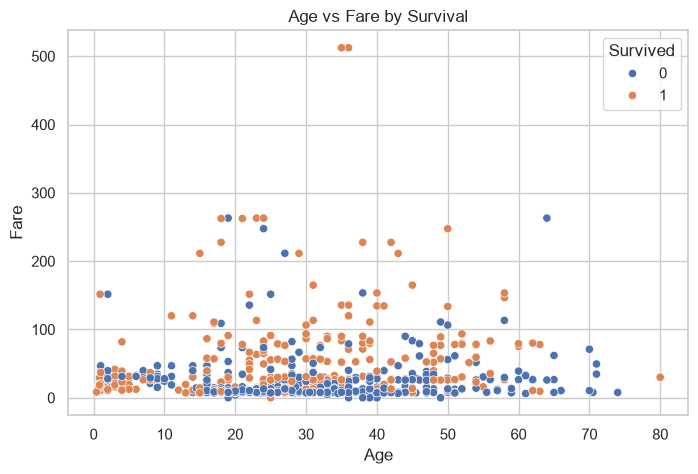

In [49]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

# 12. Outlier Analysis

## 12.1 Fare Outliers

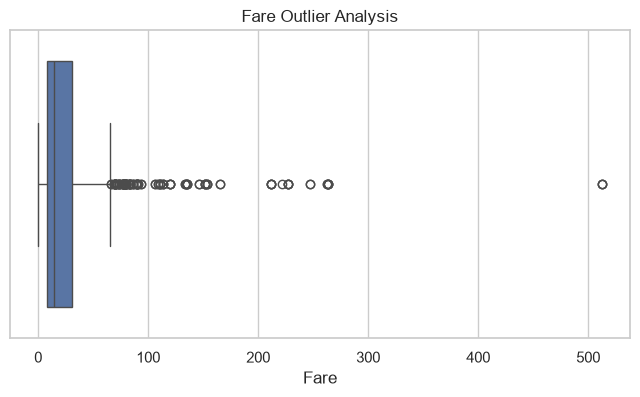

In [50]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["Fare"])

plt.title("Fare Outlier Analysis")
plt.xlabel("Fare")

plt.show()

### Observation

The Fare boxplot shows several high-value observations that may be considered potential outliers.

### Observation

The Fare boxplot shows several high-value observations that may be considered potential outliers.

In [51]:
df[["Age", "Fare", "SibSp", "Parch"]].skew()

Age      0.389108
Fare     4.787317
SibSp    3.695352
Parch    2.749117
dtype: float64

### Observation

The skewness values help identify whether numerical variables are approximately symmetric or have a longer tail on one side. Fare shows noticeable positive skewness.

# 14. Key Findings

1. The Titanic dataset contains 891 passenger records and 12 original variables.

2. Missing values are present in Age, Cabin, and Embarked.

3. Cabin contains a particularly large number of missing observations.

4. Fare is strongly right-skewed and contains high-value observations.

5. Third-class passengers form the largest passenger-class group.

6. Male passengers outnumber female passengers.

7. Female passengers have a substantially higher survival rate than male passengers.

8. Passenger class is strongly associated with survival.

9. First-class passengers generally had higher survival rates than third-class passengers.

10. Higher fares are generally associated with higher survival rates.

11. Most passengers travelled without siblings/spouses or parents/children aboard.

12. Family size shows different survival patterns.

13. The correlation heatmap provides an overview of relationships between numerical variables.

14. Overall, sex and passenger class are among the most prominent variables associated with survival.

# 15. Interview Questions

## 1. What is EDA and why is it important?

Exploratory Data Analysis (EDA) is the process of examining and understanding a dataset using statistical techniques and visualizations. It helps identify patterns, relationships, missing values, outliers, trends, and anomalies before further analysis or modeling.

## 2. Which plots do you use to check correlation?

Correlation heatmaps and scatterplots are commonly used. A heatmap allows multiple correlations to be examined simultaneously, while scatterplots show the relationship between two variables.

## 3. How do you handle skewed data?

Skewed data can be handled using transformations such as logarithmic or square-root transformations. Outliers can also be investigated and treated when appropriate.

## 4. How do you detect multicollinearity?

Multicollinearity can be detected using a correlation matrix or heatmap. Variance Inflation Factor (VIF) can also be used for formal assessment.

## 5. What are univariate, bivariate, and multivariate analyses?

Univariate analysis examines one variable, bivariate analysis examines two variables, and multivariate analysis examines three or more variables simultaneously.

## 6. Difference between heatmap and pairplot?

A heatmap uses colors to represent numerical relationships such as correlations, while a pairplot displays pairwise relationships and distributions among multiple numerical variables.

## 7. How do you summarize your insights?

Insights are summarized by identifying important patterns, relationships, trends, distributions, and anomalies discovered through statistical analysis and visualization.

# 16. Conclusion

The Exploratory Data Analysis of the Titanic dataset revealed several important patterns and relationships. Survival differed considerably according to passenger sex and passenger class. The dataset also contained missing values, particularly in the Cabin and Age variables, and the Fare variable showed significant right skewness and potential outliers.

Statistical summaries and visualizations such as histograms, boxplots, countplots, scatterplots, pairplots, and correlation heatmaps helped provide a comprehensive understanding of the dataset.